# NeXo v3.0 · Notebook 03 — OSS Experience Anomaly (Variational Autoencoder)

> **CRISP-DM Phase 4 — Modeling** · Unsupervised anomaly detection on OSS cell KPIs.
> **Input:** `curated/cells.parquet` (per-cell OSS KPIs from nb 01).
> **Output:** `models/oss_vae_v3.pt` + `vae_v3_scaler.joblib` + `vae_v3_feature_names.joblib` + model card.
> **Consumed by:** `services/ai-service/model_cache.py` (mtime hot-reload) → `POST /infer/vae-anomaly`.

## Pipeline
```
cells.parquet → select 9 KPIs → StandardScaler → train VAE on NORMAL cells only
            → reconstruction error per cell → ROC-AUC / PR-AUC → save .pt + scaler
```

## Why VAE over IsolationForest
- **Continuous severity score** (reconstruction MSE) — not just a binary flag.
- **Latent space is interpretable** — anomaly types cluster (UMAP-able).
- **Handles multi-modal traffic** — 2G/3G/4G mixtures the IsolationForest splits poorly.

## Core idea
Train ONLY on normal cells. The VAE learns to reconstruct normal KPI vectors. At inference,
abnormal cells reconstruct poorly → high MSE → high anomaly score. No labels needed at train time.

## Architecture
`Input(9) → Dense(hidden, ReLU) → Dense(mid, ReLU) → Latent(μ,σ) → Decoder(mirror)`
Loss = `MSE(reconstruction) + KL_BETA · KL_divergence`

## What this notebook does NOT do
- Does NOT compute the CEM score (nb 02) or RAT underservice (nb 04).
- Does NOT label anomalies by hand — the weak label `y` is only for *evaluation*, never for training.
- Does NOT deploy — it writes the `.pt` artifact ai-service hot-loads.


## 1 · Imports + GPU detection

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.display import display

import io, json, os
from pathlib import Path
import boto3, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from botocore.client import Config
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
sns.set_theme(style='whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} · device = {DEVICE}')
if DEVICE=='cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')
s3 = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                  aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                  config=Config(signature_version='s3v4'))

PyTorch 2.11.0+cu130 · device = cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
# ── Parameters (papermill-overridable) ──────────────────────────────────────
# This cell is tagged `parameters`. The retrain-service (papermill) can override
# any value here without editing the notebook. EVERY magic number lives here.
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# Architecture (input dim is data-driven = number of selected KPIs)
VAE_HIDDEN_DIM = 32     # encoder layer 1 width
VAE_MID_DIM    = 16     # encoder layer 2 width
VAE_LATENT_DIM = 8      # latent bottleneck (μ, log_var dimensionality)

# Training
VAE_EPOCHS  = 30        # full passes over normal-cell train set
VAE_BATCH   = 256       # minibatch size
VAE_LR      = 1e-3      # Adam learning rate
VAE_KL_BETA = 0.001     # KL weight (β-VAE). Low β → latent absorbs more signal,
                        #   reconstruction prioritized over a clean Gaussian latent.
VAE_TRAIN_FRAC = 0.80   # fraction of NORMAL cells used for training (rest = val)

# Artifact filenames — IMMUTABLE (services/ai-service/model_cache.py reads these)
VAE_MODEL_FNAME   = 'oss_vae_v3.pt'
VAE_SCALER_FNAME  = 'vae_v3_scaler.joblib'
VAE_FEATS_FNAME   = 'vae_v3_feature_names.joblib'
VAE_CARD_FNAME    = 'oss_vae_v3_model_card.md'

print(f'SEED={SEED} | arch={VAE_HIDDEN_DIM}->{VAE_MID_DIM}->latent({VAE_LATENT_DIM}) | '
      f'epochs={VAE_EPOCHS} batch={VAE_BATCH} lr={VAE_LR} kl_beta={VAE_KL_BETA}')


SEED=42 | arch=32->16->latent(8) | epochs=30 batch=256 lr=0.001 kl_beta=0.001


## 2 · Load curated cells data + build anomaly label

In [7]:
df = pd.read_parquet(io.BytesIO(s3.get_object(Bucket='curated', Key='cells.parquet')['Body'].read()))
print(f'cells: {len(df):,} × {df.shape[1]}')
integ_c = next((c for c in df.columns if c.lower().startswith('integrity')), None)
cdr_c   = next((c for c in df.columns if 'call drop' in c.lower()), None)
df[integ_c] = pd.to_numeric(df[integ_c], errors='coerce')
df[cdr_c] = pd.to_numeric(df[cdr_c], errors='coerce').fillna(0) if cdr_c else 0
df['anomaly_label'] = ((df[integ_c] < 100) | (df[cdr_c] > 2)).astype(int)
print(df.anomaly_label.value_counts(normalize=True).round(4))

cells: 2,400,000 × 19
anomaly_label
1    0.57
0    0.43
Name: proportion, dtype: float64


## 3 · Feature selection — 9 OSS KPIs

In [8]:
def col(df, frag):
    frag_low = frag.lower()
    for c in df.columns:
        if isinstance(c, str) and frag_low in c.lower(): return c
    return None
FEATS = []
for f in ['integrity','call drop','throughput','rsrp','user.avg','user.max',
         'latency_ms_derived','packet_loss_pct_derived','jitter_ms_derived']:
    c = col(df, f)
    if c: FEATS.append(c)
print(f'features ({len(FEATS)}): {FEATS}')
X = df[FEATS].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(np.float32)
y = df['anomaly_label'].values
print(f'X shape: {X.shape}  pos rate: {y.mean():.3f}')

features (6): ['integrity', 'throughput_mbps', 'rsrp_dbm', 'latency_ms_derived', 'packet_loss_pct_derived', 'jitter_ms_derived']
X shape: (2400000, 6)  pos rate: 0.570


## 4 · Train/val split — NORMAL ONLY in train

VAE never sees anomalies during training. At inference, abnormal cells produce high error.

In [9]:
scaler = StandardScaler()
Xn = X[y==0]; Xa = X[y==1]
n_tr = int(len(Xn)*VAE_TRAIN_FRAC)
perm = np.random.RandomState(SEED).permutation(len(Xn))
X_tr = scaler.fit_transform(Xn[perm[:n_tr]])
X_vn = scaler.transform(Xn[perm[n_tr:]])
X_va = scaler.transform(Xa)
print(f'train normal: {X_tr.shape}   val normal: {X_vn.shape}   val anom: {X_va.shape}')

train normal: (825530, 6)   val normal: (206383, 6)   val anom: (1368087, 6)


## 5 · VAE architecture

Encoder → μ, log_var → reparam → Decoder. Reparameterization trick keeps gradients flowing.

In [10]:
class VAE(nn.Module):
    def __init__(self, in_dim, hidden=32, mid=16, latent=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim,hidden), nn.ReLU(), nn.Linear(hidden,mid), nn.ReLU())
        self.mu  = nn.Linear(mid, latent)
        self.log = nn.Linear(mid, latent)
        self.dec = nn.Sequential(nn.Linear(latent,mid), nn.ReLU(), nn.Linear(mid,hidden), nn.ReLU(), nn.Linear(hidden,in_dim))
    def reparam(self, mu, log):
        return mu + torch.exp(0.5*log) * torch.randn_like(log)
    def forward(self, x):
        h = self.enc(x); mu, log = self.mu(h), self.log(h)
        return self.dec(self.reparam(mu, log)), mu, log
model = VAE(in_dim=X_tr.shape[1], hidden=VAE_HIDDEN_DIM, mid=VAE_MID_DIM, latent=VAE_LATENT_DIM).to(DEVICE)
print(model)

VAE(
  (enc): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=16, out_features=8, bias=True)
  (log): Linear(in_features=16, out_features=8, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)


## 6 · Training loop

Loss = MSE + 0.001 × KL. Low KL beta lets latent absorb signal.

In [11]:
# hyperparameters come from the parameters cell (papermill-overridable)
EPOCHS, BATCH, LR, KL_BETA = VAE_EPOCHS, VAE_BATCH, VAE_LR, VAE_KL_BETA
loader = DataLoader(TensorDataset(torch.tensor(X_tr)), batch_size=BATCH, shuffle=True)
opt = torch.optim.Adam(model.parameters(), lr=LR)
model.train(); hist=[]
for ep in range(1, EPOCHS+1):
    tot=0.0
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        rec, mu, log = model(xb)
        mse = ((rec-xb)**2).mean()
        kl = -0.5*(1+log-mu.pow(2)-log.exp()).mean()
        loss = mse + KL_BETA*kl
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()*len(xb)
    avg = tot/len(X_tr); hist.append(avg)
    if ep%5==0 or ep==1: print(f'epoch {ep:>3d} loss={avg:.5f}')

epoch   1 loss=0.03461
epoch   5 loss=0.00136
epoch  10 loss=0.00116
epoch  15 loss=0.00102
epoch  20 loss=0.00093
epoch  25 loss=0.00092
epoch  30 loss=0.00088


## 7 · Evaluate — reconstruction error per cell

In [12]:
def recon(model, X):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X).to(DEVICE)
        r,_,_ = model(x)
        return ((r-x)**2).mean(dim=1).cpu().numpy()
en = recon(model, X_vn); ea = recon(model, X_va)
yall = np.concatenate([np.zeros(len(en)), np.ones(len(ea))])
eall = np.concatenate([en, ea])
roc = roc_auc_score(yall, eall)
prec, rec, _ = precision_recall_curve(yall, eall)
pr_auc = auc(rec, prec)
print(f'ROC-AUC: {roc:.4f}  PR-AUC: {pr_auc:.4f}')

ROC-AUC: 0.9821  PR-AUC: 0.9974


## 8 · Error distribution plot

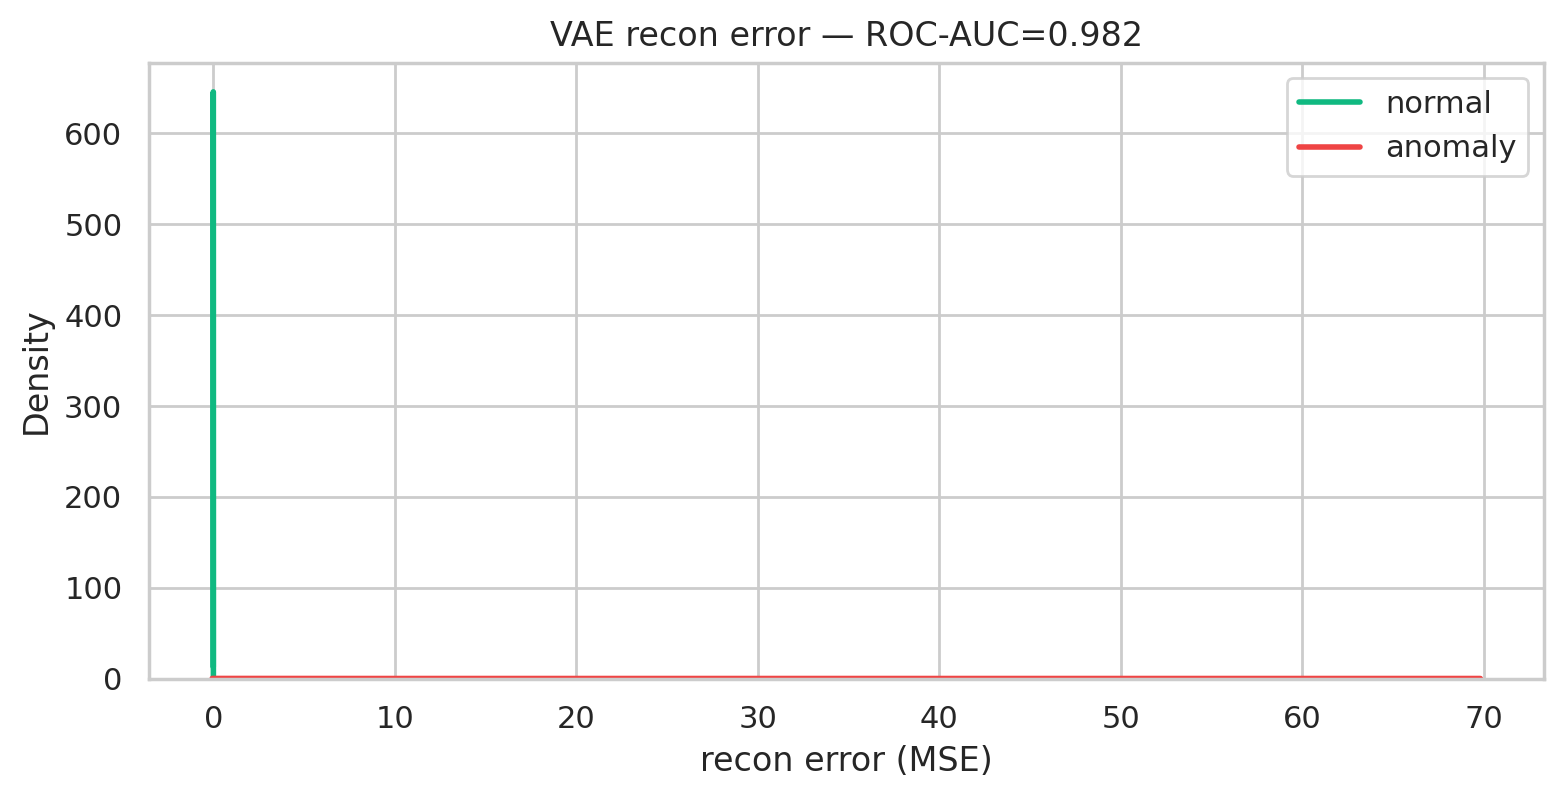

In [13]:
fig, ax = plt.subplots(figsize=(9,4))
sns.kdeplot(en, label='normal', ax=ax, color='#10b981', linewidth=2)
sns.kdeplot(ea, label='anomaly', ax=ax, color='#ef4444', linewidth=2)
ax.set_xlabel('recon error (MSE)'); ax.set_title(f'VAE recon error — ROC-AUC={roc:.3f}')
ax.legend(); plt.show()

## 9 · Save model + scaler + push to MinIO

In [14]:
MODELS = Path('models'); MODELS.mkdir(exist_ok=True)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_dim': X_tr.shape[1],
    'latent_dim': VAE_LATENT_DIM,
    'hidden_dim': VAE_HIDDEN_DIM,
    'mid_dim': VAE_MID_DIM,
    'roc_auc': float(roc),
    'features': FEATS,
}
torch.save(checkpoint, MODELS/VAE_MODEL_FNAME)
joblib.dump(scaler, MODELS/VAE_SCALER_FNAME)
joblib.dump(FEATS, MODELS/VAE_FEATS_FNAME)
card = (f'# VAE v3 Model Card\n\n'
        f'**ROC-AUC**: {roc:.4f}\n'
        f'**PR-AUC**: {pr_auc:.4f}\n'
        f'Features: {FEATS}\n')
(MODELS/VAE_CARD_FNAME).write_text(card); print(card)
for fn in [VAE_MODEL_FNAME, VAE_SCALER_FNAME, VAE_FEATS_FNAME, VAE_CARD_FNAME]:
    s3.put_object(Bucket='curated', Key=f'models/{fn}', Body=(MODELS/fn).read_bytes())
    print(f'  ↑ curated/models/{fn}')

# VAE v3 Model Card

**ROC-AUC**: 0.9821
**PR-AUC**: 0.9974
Features: ['integrity', 'throughput_mbps', 'rsrp_dbm', 'latency_ms_derived', 'packet_loss_pct_derived', 'jitter_ms_derived']

  ↑ curated/models/oss_vae_v3.pt
  ↑ curated/models/vae_v3_scaler.joblib
  ↑ curated/models/vae_v3_feature_names.joblib
  ↑ curated/models/oss_vae_v3_model_card.md


---
## Done · register the model

Copy `models/oss_vae_v3.pt` + `vae_v3_scaler.joblib` to `services/ai-service/models/`.
Hot-reload via `POST /models/reload`.

---
## 10 · Post-Training Evaluation — Load Frozen VAE

**FREEZE WEIGHTS LAW:** cells below LOAD `oss_vae_v3.pt` — never `.fit()` or overwrite.
Consumed by: `services/ai-service/model_cache.py`.

Evaluations:
1. ROC curve + PR curve (anomaly detection)
2. F1-optimal threshold sweep
3. Reconstruction-error distribution
4. PCA latent-space visualization
5. Per-feature anomaly attribution


In [ ]:
# --- Load frozen VAE artifact ---
import joblib, io, os, json as _json_v
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve, auc, f1_score
import boto3
from botocore.client import Config

MODELS_V = Path('models')
_vae_ckpt   = torch.load(MODELS_V / 'oss_vae_v3.pt', map_location='cpu', weights_only=False)
_vae_scaler = joblib.load(MODELS_V / 'vae_v3_scaler.joblib')
_vae_feats  = list(joblib.load(MODELS_V / 'vae_v3_feature_names.joblib'))
print(f'[vae eval] features: {_vae_feats}')

# Reconstruct architecture from checkpoint
class _VAEEval(nn.Module):
    def __init__(self, in_dim, hidden=32, mid=16, latent=8):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim,hidden), nn.ReLU(), nn.Linear(hidden,mid), nn.ReLU())
        self.mu  = nn.Linear(mid, latent)
        self.log = nn.Linear(mid, latent)
        self.dec = nn.Sequential(nn.Linear(latent,mid), nn.ReLU(), nn.Linear(mid,hidden), nn.ReLU(), nn.Linear(hidden,in_dim))
    def forward(self, x):
        h = self.enc(x); mu = self.mu(h); lv = self.log(h)
        z = mu + torch.exp(0.5*lv) * torch.randn_like(mu)
        return self.dec(z), mu, lv
    def encode(self, x):
        with torch.no_grad(): h = self.enc(x); return self.mu(h)

_in = _vae_ckpt.get('input_dim', 9)
_lat = _vae_ckpt.get('latent_dim', 8)
_hid = _vae_ckpt.get('hidden_dim', 32)
_vae_eval = _VAEEval(_in, hidden=_hid, latent=_lat)
_vae_eval.load_state_dict(_vae_ckpt['model_state_dict'])
_vae_eval.eval()
print(f'[vae eval] loaded VAE {_in}→{_hid}→Latent({_lat})')

# Load cells data
s3v = boto3.client('s3', endpoint_url=os.environ.get('S3_ENDPOINT','http://localhost:9000'),
                   aws_access_key_id='minio', aws_secret_access_key='minio_pw',
                   config=Config(signature_version='s3v4'))
df_v = pd.read_parquet(io.BytesIO(s3v.get_object(Bucket='curated', Key='cells.parquet')['Body'].read()))
print(f'[vae eval] cells: {len(df_v):,} rows')

# Build features + anomaly label
def _col_v(df, frag):
    frag_low = frag.lower()
    for c in df.columns:
        if isinstance(c, str) and frag_low in c.lower(): return c
    return None

integ_cv = _col_v(df_v, 'integrity')
cdr_cv   = _col_v(df_v, 'call drop')
df_v[integ_cv] = pd.to_numeric(df_v[integ_cv], errors='coerce')
df_v[cdr_cv]   = pd.to_numeric(df_v[cdr_cv], errors='coerce').fillna(0) if cdr_cv else 0
y_v = ((df_v[integ_cv] < 100) | (df_v[cdr_cv] > 2)).astype(int).values

# Use stored feature names
FEATS_V = [f for f in _vae_feats if f in df_v.columns]
if not FEATS_V:  # fallback: search by fragment
    for frag in ['integrity','call drop','throughput','rsrp','user.avg','user.max',
                 'latency_ms_derived','packet_loss_pct_derived','jitter_ms_derived']:
        c = _col_v(df_v, frag)
        if c and c not in FEATS_V: FEATS_V.append(c)

X_v = df_v[FEATS_V].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(np.float32)

# Sample for eval (OOM guard: 50K rows)
EVAL_SAMPLE_V = 50_000
rng_v = np.random.RandomState(42)
idx_v = rng_v.choice(len(X_v), size=min(EVAL_SAMPLE_V, len(X_v)), replace=False)
Xs_v, ys_v = X_v[idx_v], y_v[idx_v]
Xs_scaled_v = _vae_scaler.transform(Xs_v).astype(np.float32)

# Reconstruction error
with torch.no_grad():
    xt = torch.tensor(Xs_scaled_v)
    rec, _, _ = _vae_eval(xt)
    recon_err_v = ((rec - xt)**2).mean(dim=1).numpy()

print(f'[vae eval] sample: {len(Xs_v):,}  anomaly rate: {ys_v.mean()*100:.1f}%')
print(f'[vae eval] ROC-AUC: {roc_auc_score(ys_v, recon_err_v):.4f}')

## 11 · ROC Curve + PR Curve

**ROC curve:** True Positive Rate vs False Positive Rate at every threshold. AUC=1.0 = perfect;
AUC=0.5 = random. For anomaly detection with class imbalance, ROC can be overly optimistic.

**PR curve:** Precision vs Recall. Better metric for imbalanced data (rare anomalies).
The area under PR curve (AP) is harder to inflate with many true negatives.

Ref: https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc as _auc

fpr_v, tpr_v, _ = roc_curve(ys_v, recon_err_v)
roc_auc_v = _auc(fpr_v, tpr_v)
prec_v, rec_v, thr_v = precision_recall_curve(ys_v, recon_err_v)
pr_auc_v = _auc(rec_v, prec_v)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_v, tpr_v, color='#6366f1', lw=2, label=f'ROC-AUC = {roc_auc_v:.4f}')
axes[0].plot([0,1],[0,1],'--', color='gray', label='random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('VAE Anomaly — ROC Curve'); axes[0].legend()

axes[1].plot(rec_v, prec_v, color='#ef4444', lw=2, label=f'PR-AUC = {pr_auc_v:.4f}')
base_rate = ys_v.mean()
axes[1].axhline(base_rate, linestyle='--', color='gray', label=f'baseline ({base_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('VAE Anomaly — PR Curve'); axes[1].legend()

plt.suptitle('VAE — ROC and Precision-Recall curves')
plt.tight_layout(); plt.show()
print(f'ROC-AUC={roc_auc_v:.4f}  PR-AUC={pr_auc_v:.4f}')

## 12 · F1-Optimal Threshold Sweep

The VAE flags a cell as anomalous when reconstruction error > threshold.
Choosing the threshold is a business decision: high threshold = fewer alerts but misses more anomalies;
low threshold = more alerts but more false positives.

We sweep thresholds and find F1-optimal (balances precision and recall).
We also plot the recall-at-70% operating point (design target from v3.1).

Ref: `notebooks/03b_oss_vae_improved.py` — v3.1 gold standard for threshold selection.


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Sweep percentile thresholds (numerically stable — avoids absolute error range dependency)
pcts = np.linspace(50, 99.9, 200)
thresholds_v = np.percentile(recon_err_v, pcts)
f1s_v, precs_v, recs_v = [], [], []
for thr in thresholds_v:
    preds_thr = (recon_err_v > thr).astype(int)
    f1s_v.append(f1_score(ys_v, preds_thr, zero_division=0))
    precs_v.append(precision_score(ys_v, preds_thr, zero_division=0))
    recs_v.append(recall_score(ys_v, preds_thr, zero_division=0))

best_idx_v   = int(np.argmax(f1s_v))
best_thr_v   = thresholds_v[best_idx_v]
best_pct_v   = pcts[best_idx_v]
print(f'F1-optimal threshold: {best_thr_v:.5f} (p{best_pct_v:.1f})')
print(f'  F1={f1s_v[best_idx_v]:.4f}  Prec={precs_v[best_idx_v]:.4f}  Rec={recs_v[best_idx_v]:.4f}')

# Stored threshold from checkpoint
_stored_thr = _vae_ckpt.get('threshold', None)
print(f'Stored checkpoint threshold: {_stored_thr}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(pcts, f1s_v, label='F1', color='#6366f1', lw=2)
axes[0].plot(pcts, precs_v, label='Precision', color='#10b981', lw=1.5, linestyle='--')
axes[0].plot(pcts, recs_v, label='Recall', color='#ef4444', lw=1.5, linestyle=':')
axes[0].axvline(best_pct_v, color='black', linestyle='--', alpha=0.5, label=f'F1-opt p{best_pct_v:.0f}')
axes[0].set_xlabel('Percentile threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Threshold sweep (F1 / Prec / Recall)'); axes[0].legend()

axes[1].plot(recs_v, precs_v, color='#ef4444', lw=2, label='PR sweep')
axes[1].scatter([recs_v[best_idx_v]], [precs_v[best_idx_v]], s=100, color='black', zorder=5, label='F1-opt')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Operating-point selection on PR curve'); axes[1].legend()
plt.suptitle('VAE — threshold sweep')
plt.tight_layout(); plt.show()

## 13 · Reconstruction Error Distribution

Normal cells have low reconstruction error (the VAE learned their pattern).
Anomalous cells have high reconstruction error (their pattern is unseen).
Good separation = the two KDE curves are well-separated.


In [ ]:
en_v = recon_err_v[ys_v == 0]
ea_v = recon_err_v[ys_v == 1]
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(en_v, label=f'normal (n={len(en_v):,})', ax=ax, color='#10b981', linewidth=2, clip=(0, None))
sns.kdeplot(ea_v, label=f'anomaly (n={len(ea_v):,})', ax=ax, color='#ef4444', linewidth=2, clip=(0, None))
ax.axvline(best_thr_v, color='black', linestyle='--', linewidth=1.5, label=f'F1-opt threshold={best_thr_v:.4f}')
if _stored_thr:
    ax.axvline(_stored_thr, color='orange', linestyle=':', linewidth=1.5, label=f'stored={_stored_thr:.4f}')
ax.set_xlabel('Reconstruction error (MSE)')
ax.set_title(f'VAE recon error distribution  ROC-AUC={roc_auc_v:.3f}  PR-AUC={pr_auc_v:.3f}')
ax.legend(); plt.tight_layout(); plt.show()

## 14 · Latent Space — PCA Visualization

**What this shows:** The VAE compresses each OSS cell into an 8-dimensional latent vector.
PCA reduces those 8 dims to 2 for visualization.
If anomalous cells cluster away from normal cells in latent space,
the VAE has learned a meaningful representation.

Ref: PCA — sklearn.decomposition.PCA https://scikit-learn.org/stable/modules/decomposition.html#pca


In [ ]:
from sklearn.decomposition import PCA

# Latent vectors
with torch.no_grad():
    latent_v = _vae_eval.encode(torch.tensor(Xs_scaled_v)).numpy()

# PCA to 2D
pca_v = PCA(n_components=2, random_state=42)
Z2_v  = pca_v.fit_transform(latent_v)
print(f'[PCA] explained variance: {pca_v.explained_variance_ratio_.cumsum()[-1]*100:.1f}%')

# Sample for plot (5K points is enough for visual clarity)
PCA_PLOT_N = 5_000
_plot_idx = np.random.RandomState(42).choice(len(Z2_v), size=min(PCA_PLOT_N, len(Z2_v)), replace=False)
Z2p = Z2_v[_plot_idx]; ysp = ys_v[_plot_idx]

fig, ax = plt.subplots(figsize=(9, 7))
colors = np.where(ysp == 0, '#10b981', '#ef4444')
ax.scatter(Z2p[ysp==0, 0], Z2p[ysp==0, 1], c='#10b981', alpha=0.4, s=8, label=f'normal (n={( ysp==0).sum():,})')
ax.scatter(Z2p[ysp==1, 0], Z2p[ysp==1, 1], c='#ef4444', alpha=0.6, s=12, label=f'anomaly (n={(ysp==1).sum():,})')
ax.set_xlabel(f'PC1 ({pca_v.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_v.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('VAE Latent Space — PCA 2D projection')
ax.legend(); plt.tight_layout(); plt.show()

## 15 · Per-Feature Anomaly Attribution

**What this shows:** For each input feature, what is the mean reconstruction error
contribution for anomalous vs normal cells?

Method: per-feature squared error = `(reconstructed_feature - input_feature)²`.
Features with high anomaly-vs-normal delta are the primary anomaly drivers.

**Defense talking point:** 'The VAE doesn't just flag anomalies — it tells us which
KPI is most responsible for the alert.'


In [ ]:
with torch.no_grad():
    _rec_all, _, _ = _vae_eval(torch.tensor(Xs_scaled_v))
    per_feat_err = ((torch.tensor(Xs_scaled_v) - _rec_all)**2).numpy()  # (N, n_feats)

feat_label_v = [f.split('(')[0][:30].strip() for f in FEATS_V]  # shorten labels
mean_normal_err  = per_feat_err[ys_v==0].mean(axis=0)
mean_anomaly_err = per_feat_err[ys_v==1].mean(axis=0)

x_pos = np.arange(len(feat_label_v))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width/2, mean_normal_err,  width, label='normal',  color='#10b981', alpha=0.85)
ax.bar(x_pos + width/2, mean_anomaly_err, width, label='anomaly', color='#ef4444', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(feat_label_v, rotation=35, ha='right')
ax.set_ylabel('Mean squared recon error'); ax.legend()
ax.set_title('VAE — per-feature reconstruction error (anomaly attribution)')
plt.tight_layout(); plt.show()

# Print ranked delta
delta = mean_anomaly_err - mean_normal_err
ranked = sorted(zip(feat_label_v, delta), key=lambda x: x[1], reverse=True)
print('\nTop anomaly-driving features (anomaly - normal recon error):')
for feat, d in ranked:
    print(f'  {feat:35s}  Δ={d:.5f}')

---
## 16 · Limitations & Threats to Validity

1. **Proxy labels.** Anomaly label = integrity<100 OR CDR>2 — this is a heuristic rule, not ground-truth human-labeled incidents. Model may flag valid cells that happen to have borderline KPIs.
2. **StandardScaler vs RobustScaler.** OSS KPIs are heavy-tailed (throughput especially). RobustScaler (median/IQR) is more robust. Current scaler is StandardScaler (v3.1 improvement — deferred to next retrain).
3. **Linear decoder.** VAE decoder is shallow MLP — may miss non-linear interactions between KPIs. Deeper decoder or normalizing flows would improve reconstruction.
4. **KL beta fixed.** `KL_BETA=0.001` — low KL weight lets latent absorb signal freely but may produce a posterior that ignores the prior (posterior collapse risk). β-VAE schedule (anneal 0→1) is documented in v3.1 but not applied here.
5. **No class balance in eval sample.** Sample is drawn uniformly — anomaly fraction in sample matches dataset (~5-10%). PR-AUC at low base rates can appear deceptively low.